# Environment: Frozen Lake

- `S` = start

- `F` = frozen surface, safe cell

- `H` = hole

- `G` = goal


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


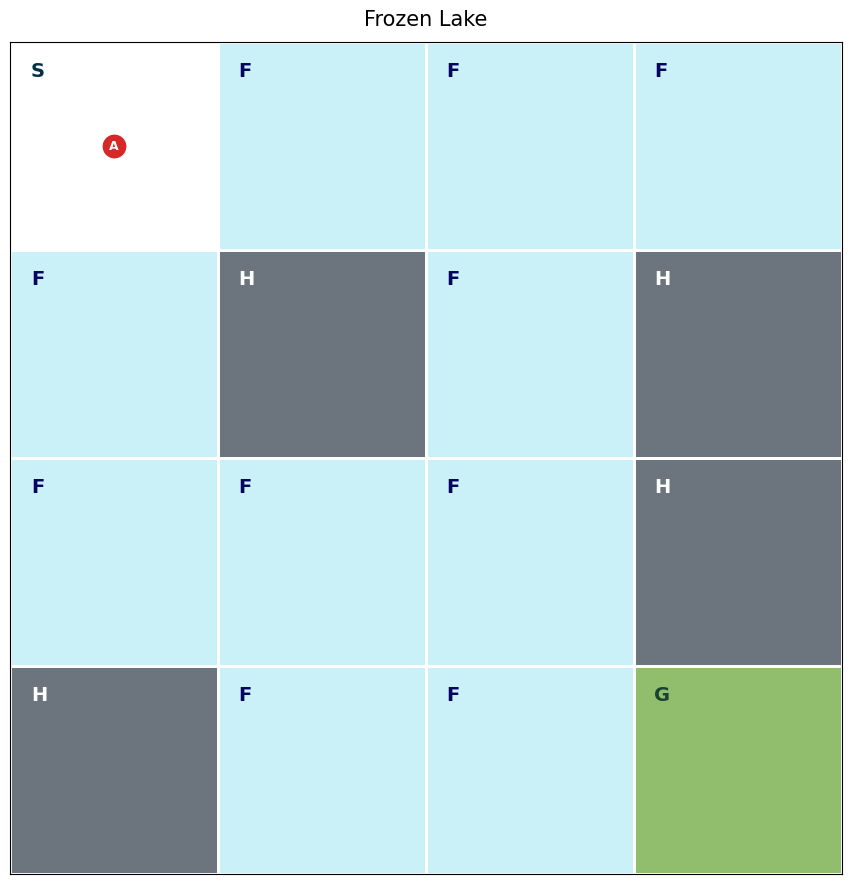

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from env_frozen_lake import FrozenLakeEnv
from env_frozen_lake_visualize import env_frozen_lake_visualize, env_frozen_lake_random_policy_demo, env_frozen_lake_policy_visualize

env = FrozenLakeEnv()
env_frozen_lake_visualize(env, transition_probability=False)

### Environment functions

- `env.reset()` resets the environment and returns the initial state.

- `env.step(action)` applies an action and returns `(next_state, reward, done, info)`.

- `env.get_all_states()` returns all states of the environment, including the hidden absorbing state `TERMINAL`.

- `env.get_possible_actions(state)` returns all actions available in a given state.

- `env.get_next_states(state, action)` returns a dictionary of possible next states and their probabilities.

- `env.get_transition_prob(state, action, next_state)` returns the transition probability to `next_state`.

- `env.get_reward(state, action)` returns the reward for the chosen action in the current state.

- `env.is_terminal(state)` checks whether the state is terminal.


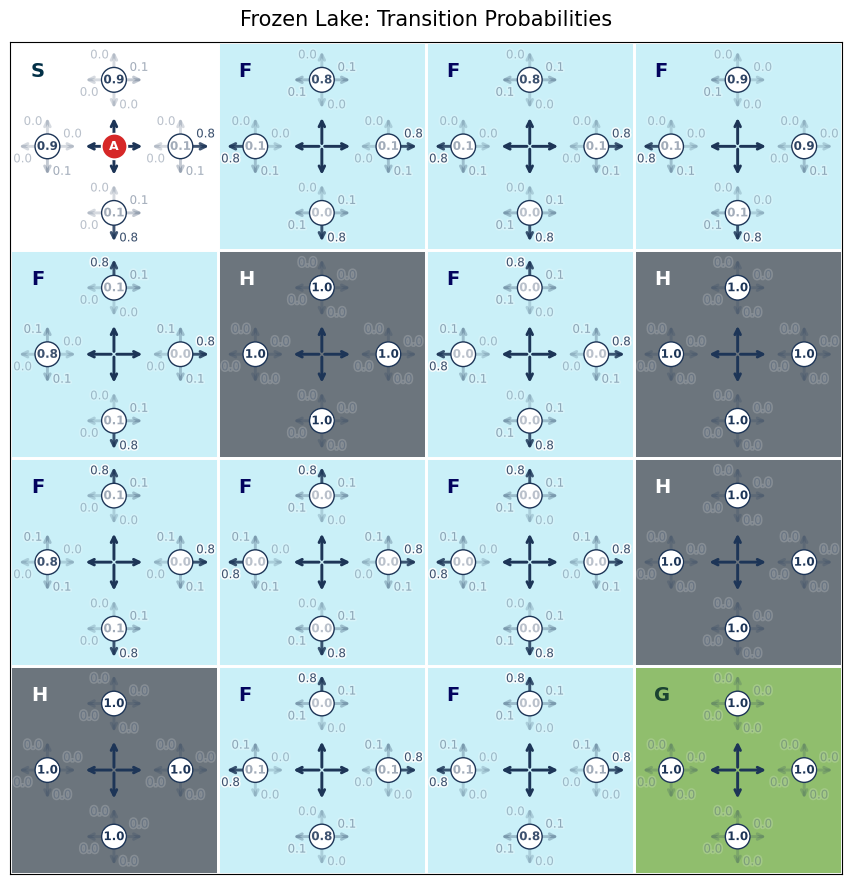

In [2]:
env_frozen_lake_visualize(env, transition_probability=True)

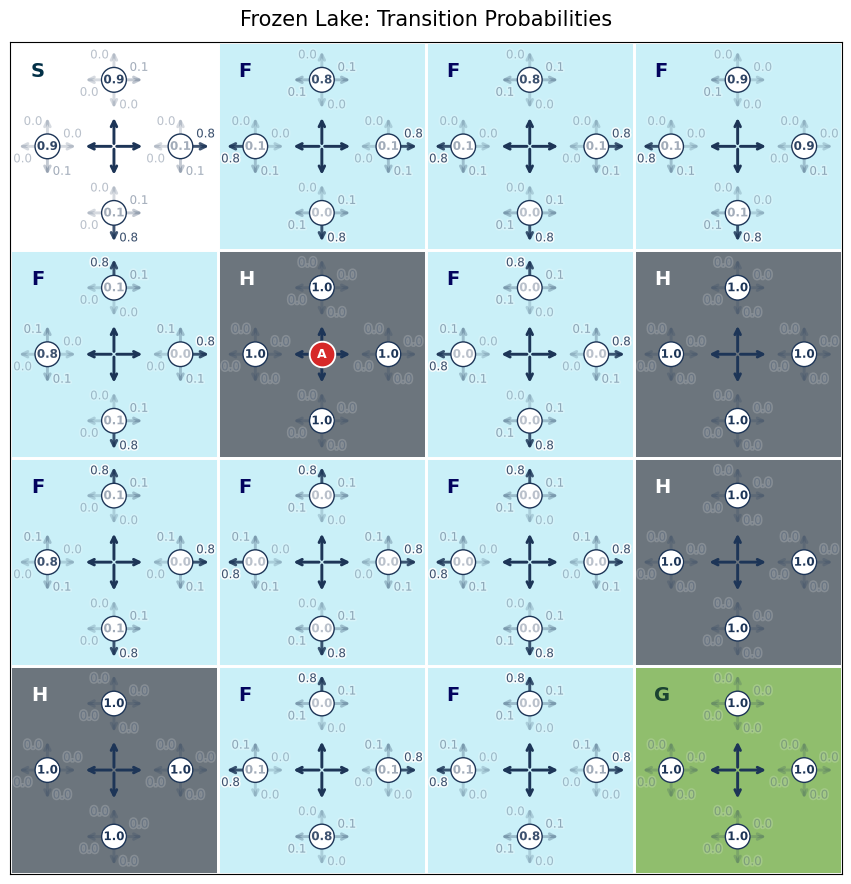

In [3]:
env_frozen_lake_random_policy_demo(env, delay=0.5, seed=0)

# Policy Iterations

Let $\pi^0$ and $L,K \in \mathbb N$.

For each $k \in \overline{0,K}$, do

- (Policy evaluation) Iterative Policy Evaluation
$$
v^{l+1}(s)= \sum\limits_{a} \pi(a|s) \Big(\mathcal{R}(s,a) + \gamma \sum\limits_{s'} \mathcal{P}(s'|s,a) v^l(s')\Big),\quad s \in \mathcal{S},\quad l \in \overline{0,L-1}
$$
Define $q^L(s,a)$ by $v^L(s)$:
$$
q^L(s,a) = R(s, a) + \gamma \sum_{s'} P(s'|s,a) v^L(s').
$$
- (Policy improvement) Greedy Policy Improvement
$$
\pi^{k+1}(a|s) =
\left\{
\begin{array}{l}
1, \text{ if } a \in \mathrm{argmax}_{a' \in \mathcal{A}}\, q^L(s,a')\\[0.2cm]
0, \text{ otherwise }
\end{array}
\right.
$$

In [4]:
def get_q_values(values, gamma):
    q_values = {}
    for state in env.get_all_states():
        q_values[state] = {}
        for action in env.get_possible_actions(state):
            q_values[state][action] = env.get_reward(state, action)
            for next_state in env.get_next_states(state, action):
                q_values[state][action] += gamma * env.get_transition_prob(state, action, next_state) * values[next_state]
    return q_values

In [5]:
def init_policy():
    policy = {}
    for state in env.get_all_states():
        policy[state] = {}
        for action in env.get_possible_actions(state):
            policy[state][action] = 1 / len(env.get_possible_actions(state))
    return policy

def init_values():
    values = {}
    for state in env.get_all_states():
        values[state] = 0
    return values

In [6]:
def culc_values(policy, gamma, L):
    values = init_values()
    for _ in range(L):
        new_values = init_values()
        q_values = get_q_values(values, gamma)
        for state in env.get_all_states():
            for action in env.get_possible_actions(state):
                new_values[state] += policy[state][action] * q_values[state][action]
        values = new_values
    return values


In [7]:
def policy_improvement(q_values):
    policy = init_policy()
    for state in env.get_all_states():
        if len(env.get_possible_actions(state)) > 0:
            max_i = np.argmax(list(q_values[state].values()))
            max_action = env.get_possible_actions(state)[max_i]
            for action in env.get_possible_actions(state):
                policy[state][action] = 1 if action == max_action else 0
    return policy

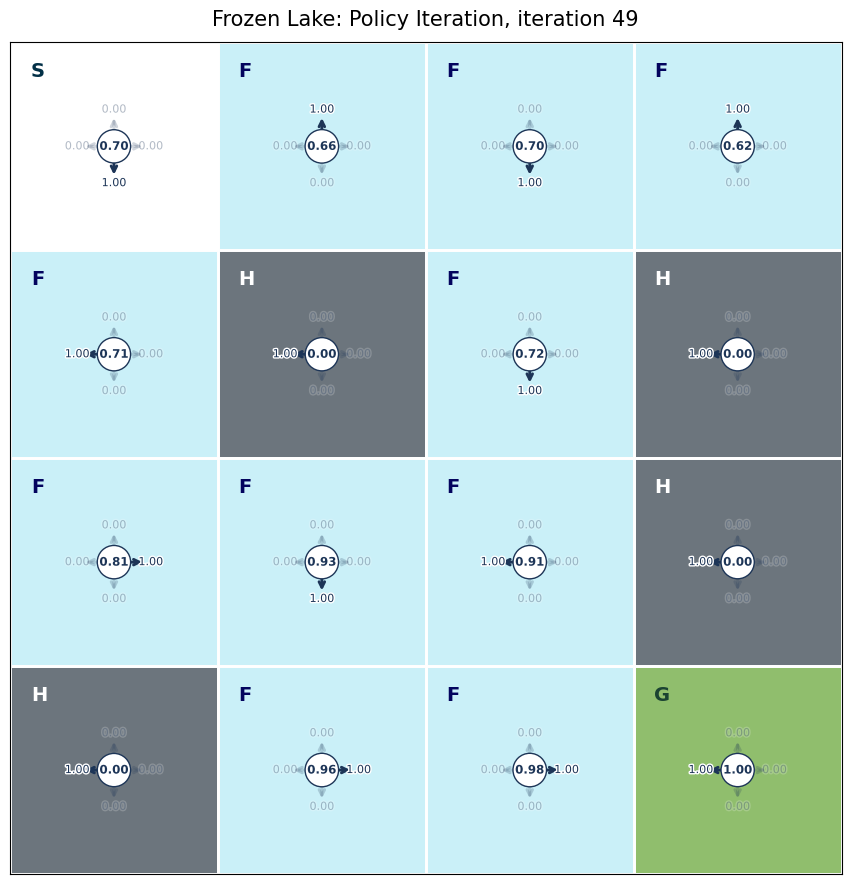

In [9]:
K = 50
L = 50
gamma = 0.99

policy = init_policy()
for k in range(K):
    # policy evaluation
    values = culc_values(policy, gamma, L)
    q_values = get_q_values(values, gamma)

    # policy improvement
    policy = policy_improvement(q_values)

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(2.7 * env.desc.shape[1], 2.7 * env.desc.shape[0]))
    env_frozen_lake_policy_visualize(env, values, policy, ax=ax, iteration=k)
    display(fig)
    plt.close(fig)


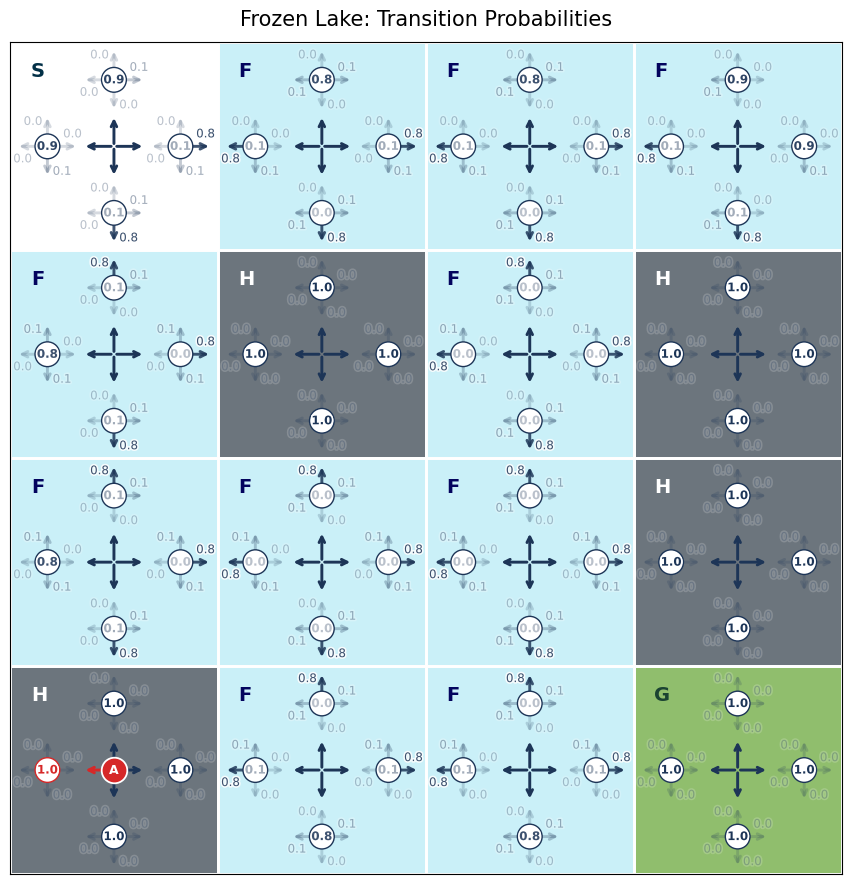

In [10]:
move_to_action = {
    (-1, 0): "up",
    (1, 0): "down",
    (0, -1): "left",
    (0, 1): "right",
    (0, 0): "stay",
}

state = env.reset()
try:
    while True:
        fig, ax = plt.subplots(figsize=(2.7 * env.desc.shape[1], 2.7 * env.desc.shape[0]))
        env_frozen_lake_visualize(env, state=state, ax=ax)
        display(fig)
        plt.close(fig)
        time.sleep(0.5)

        actions = env.get_possible_actions(state)
        if len(actions) == 0:
            state = env.reset()
            clear_output(wait=True)
            continue

        current_state = state
        action_probs = policy[current_state]
        action = max(action_probs, key=action_probs.get)
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(2.7 * env.desc.shape[1], 2.7 * env.desc.shape[0]))
        env_frozen_lake_visualize(
            env,
            state=current_state,
            ax=ax,
            active_state=current_state,
            selected_action=action,
        )
        display(fig)
        plt.close(fig)
        time.sleep(0.5)

        state, reward, done, _ = env.step(action)
        if isinstance(state, tuple) and isinstance(current_state, tuple):
            realized_move = move_to_action[(state[0] - current_state[0], state[1] - current_state[1])]
        else:
            realized_move = None
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(2.7 * env.desc.shape[1], 2.7 * env.desc.shape[0]))
        env_frozen_lake_visualize(
            env,
            state=current_state,
            ax=ax,
            active_state=current_state,
            selected_action=action,
            realized_move=realized_move,
        )
        display(fig)
        plt.close(fig)
        time.sleep(0.5)

        if done:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(2.7 * env.desc.shape[1], 2.7 * env.desc.shape[0]))
            env_frozen_lake_visualize(env, state=state, ax=ax)
            display(fig)
            plt.close(fig)
            time.sleep(0.5)

            state = env.reset()
            clear_output(wait=True)
            continue

        clear_output(wait=True)
except KeyboardInterrupt:
    clear_output(wait=True)
